In [1]:
import pandas as pd
df = pd.read_csv("ai4i2020.csv")
print("Data inserted successfully")


Data inserted successfully


In [2]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.shape

(10000, 14)

In [4]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [5]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [7]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [8]:
df.describe(include = 'object')

,Product ID,Type
count,10000,10000
unique,10000,3
top,M14860,L
freq,1,6000


In [9]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [10]:
df.isnull().values.any()

np.False_

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df[df.duplicated()]


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF


In [13]:
feature_columns = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Type'
]

target_column = 'Machine failure'

feature_columns, target_column


(['Air temperature [K]',
  'Process temperature [K]',
  'Rotational speed [rpm]',
  'Torque [Nm]',
  'Tool wear [min]',
  'Type'],
 'Machine failure')

In [14]:
df['Machine failure'].value_counts()


Machine failure
0    9661
1     339
Name: count, dtype: int64

In [15]:
df['Machine failure'].value_counts(normalize=True) * 100


Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [16]:
numeric_columns = df.select_dtypes(include='number')
numeric_columns.head()


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [17]:
numeric_columns.describe()


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


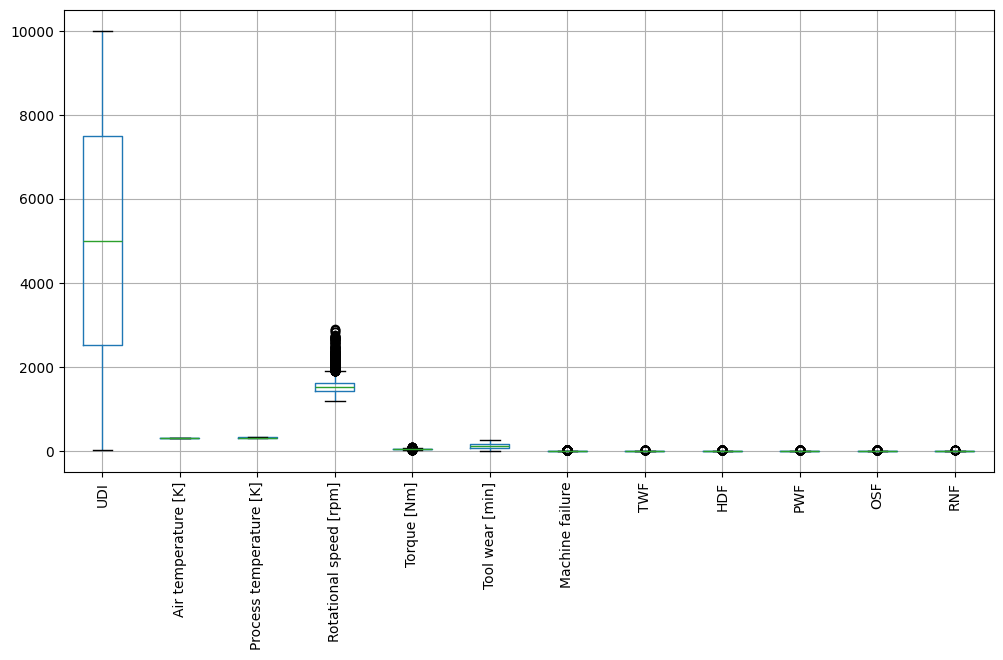

In [18]:
import matplotlib.pyplot as plt

numeric_columns.boxplot(figsize=(12,6))
plt.xticks(rotation=90)
plt.show()


In [19]:
df_clean = df.copy()

In [20]:
df_clean.drop(columns=['UDI'], inplace=True)


In [21]:
failure_type_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

df_clean.drop(columns=failure_type_cols, inplace=True)


In [22]:
df_clean.columns


Index(['Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='object')

In [23]:
df_clean.shape


(10000, 8)

In [24]:
df_clean['Machine failure'].value_counts()


Machine failure
0    9661
1     339
Name: count, dtype: int64

In [25]:
df_clean['Machine failure'].value_counts(normalize=True) * 100


Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [26]:
num_cols = df_clean.select_dtypes(include='number').columns
num_cols


Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='object')

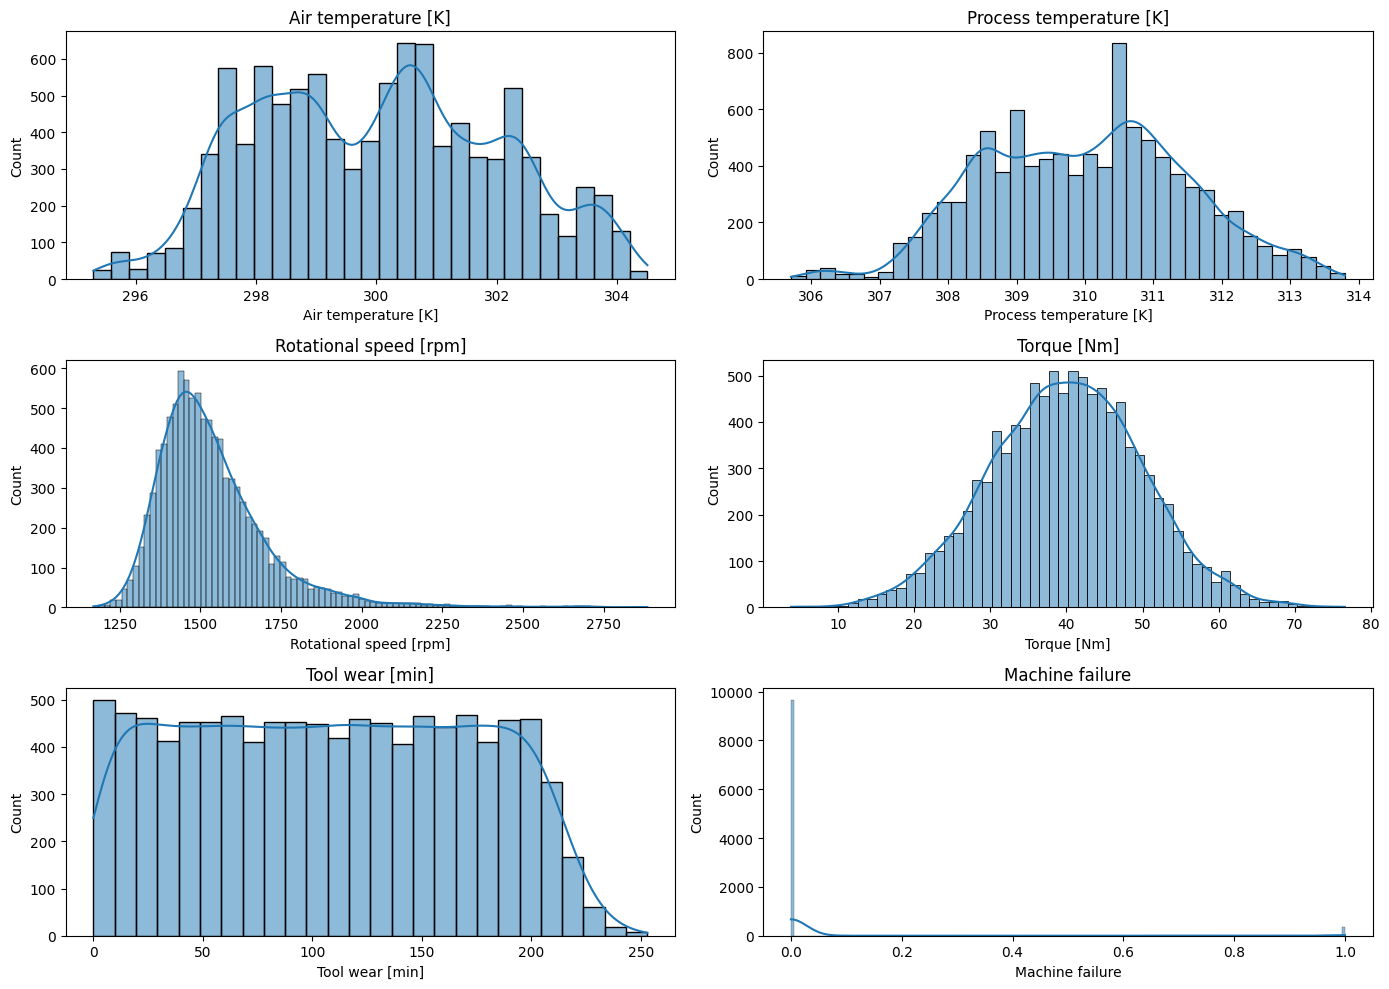

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df_clean[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show() 


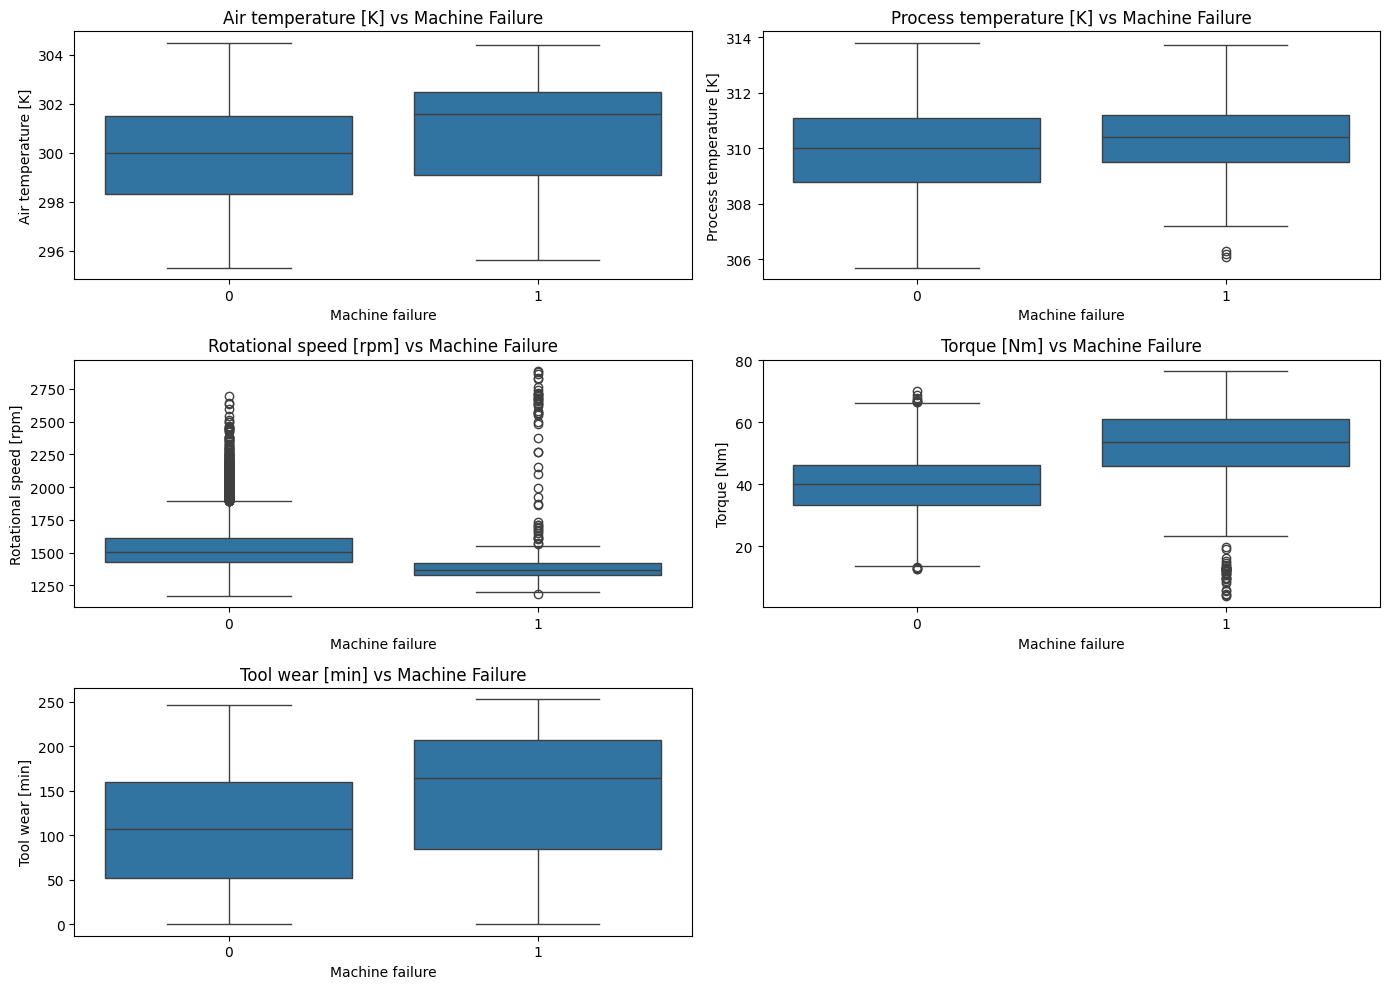

In [28]:
plt.figure(figsize=(14,10))
for i, col in enumerate(num_cols[:-1], 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x='Machine failure', y=col, data=df_clean)
    plt.title(f"{col} vs Machine Failure")

plt.tight_layout()
plt.show()


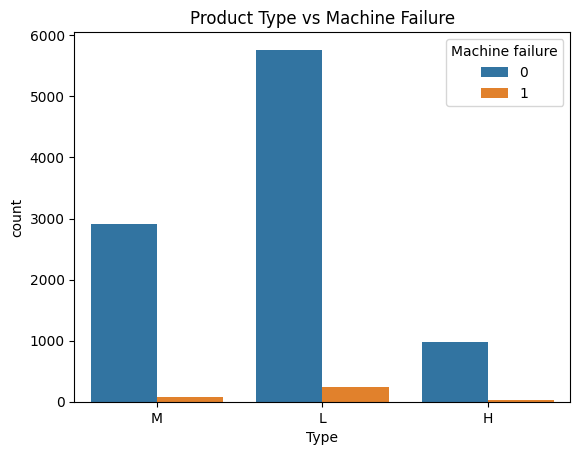

In [29]:
sns.countplot(x='Type', hue='Machine failure', data=df_clean)
plt.title("Product Type vs Machine Failure")
plt.show()


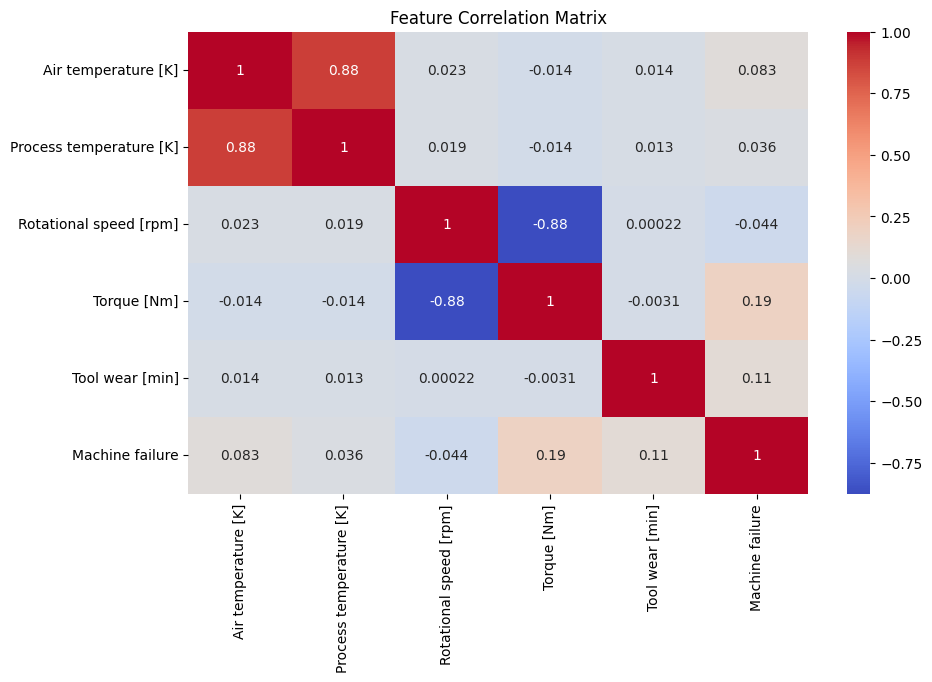

In [30]:
plt.figure(figsize=(10,6))
sns.heatmap(df_clean[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


In [31]:
X = df_clean.drop(columns=['Machine failure'])
y = df_clean['Machine failure']


In [32]:
X.shape, y.shape


((10000, 7), (10000,))

In [33]:
X = pd.get_dummies(X, columns=['Type'], drop_first=True)


In [34]:
X.head()

,Product ID,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,M14860,298.1,308.6,1551,42.8,0,False,True
1,L47181,298.2,308.7,1408,46.3,3,True,False
2,L47182,298.1,308.5,1498,49.4,5,True,False
3,L47183,298.2,308.6,1433,39.5,7,True,False
4,L47184,298.2,308.7,1408,40.0,9,True,False


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [36]:
X_train.shape, X_test.shape


((8000, 8), (2000, 8))

In [37]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)


Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [39]:
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)


In [40]:
df_clean = df_clean.drop(columns=['Product ID'])


In [41]:
X = df_clean.drop(columns=['Machine failure'])
y = df_clean['Machine failure']


In [42]:
X = pd.get_dummies(X, columns=['Type'], drop_first=True)


In [43]:
X.head()



,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [45]:
X_train.dtypes


Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Type_L                        bool
Type_M                        bool
dtype: object

In [46]:
baseline_model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [47]:
y_pred = baseline_model.predict(X_test)


In [48]:

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.14      0.82      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.83      0.88      2000



In [49]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)


array([[1599,  333],
       [  12,   56]])

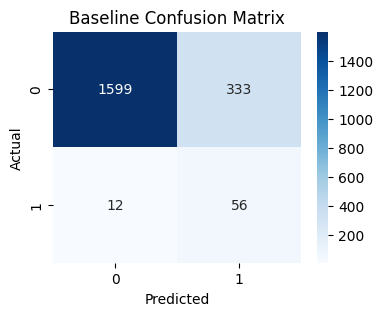

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Confusion Matrix")
plt.show()


In [51]:
def engineer_features(df):
    df_fe = df.copy()
    
    # 1️⃣ Thermal stress feature
    df_fe['temp_diff'] = df_fe['Process temperature [K]'] - df_fe['Air temperature [K]']
    
    # 2️⃣ Mechanical load feature
    df_fe['torque_per_rpm'] = df_fe['Torque [Nm]'] / df_fe['Rotational speed [rpm]']
    
    # 3️⃣ Wear-load interaction
    df_fe['wear_torque_interaction'] = df_fe['Tool wear [min]'] * df_fe['Torque [Nm]']
    
    # 4️⃣ Simple risk flag (domain logic)
    df_fe['high_wear_high_torque'] = (
        (df_fe['Tool wear [min]'] > df_fe['Tool wear [min]'].median()) &
        (df_fe['Torque [Nm]'] > df_fe['Torque [Nm]'].median())
    ).astype(int)
    
    return df_fe


In [52]:
X_train_fe = engineer_features(X_train)


In [53]:
X_test_fe = engineer_features(X_test)


In [54]:
X_train_fe.shape, X_test_fe.shape


((8000, 11), (2000, 11))

In [55]:
baseline_model_fe = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

baseline_model_fe.fit(X_train_fe, y_train)


c:\Users\Ch.Anirudh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [56]:
y_pred_fe = baseline_model_fe.predict(X_test_fe)

print(classification_report(y_test, y_pred_fe))


              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.15      0.84      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.58      2000
weighted avg       0.96      0.83      0.88      2000



In [57]:
confusion_matrix(y_test, y_pred_fe)


array([[1599,  333],
       [  11,   57]])

In [58]:
y_proba = baseline_model_fe.predict_proba(X_test_fe)[:, 1]


In [59]:
import numpy as np

y_pred_thresh = (y_proba >= 0.7).astype(int)


In [60]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_thresh))
confusion_matrix(y_test, y_pred_thresh)


              precision    recall  f1-score   support

           0       0.99      0.92      0.95      1932
           1       0.23      0.69      0.35        68

    accuracy                           0.91      2000
   macro avg       0.61      0.80      0.65      2000
weighted avg       0.96      0.91      0.93      2000



array([[1775,  157],
       [  21,   47]])

In [61]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_fe, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [62]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_rf = rf_model.predict(X_test_fe)

print(classification_report(y_test, y_pred_rf))
confusion_matrix(y_test, y_pred_rf)


              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.93      0.74      0.82        68

    accuracy                           0.99      2000
   macro avg       0.96      0.87      0.91      2000
weighted avg       0.99      0.99      0.99      2000



array([[1928,    4],
       [  18,   50]])

In [63]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train_fe.columns
).sort_values(ascending=False)

feature_importance


torque_per_rpm             0.211141
Rotational speed [rpm]     0.198737
Torque [Nm]                0.178591
Tool wear [min]            0.133745
wear_torque_interaction    0.111308
temp_diff                  0.076851
Air temperature [K]        0.043839
Process temperature [K]    0.029399
high_wear_high_torque      0.007694
Type_L                     0.004741
Type_M                     0.003954
dtype: float64

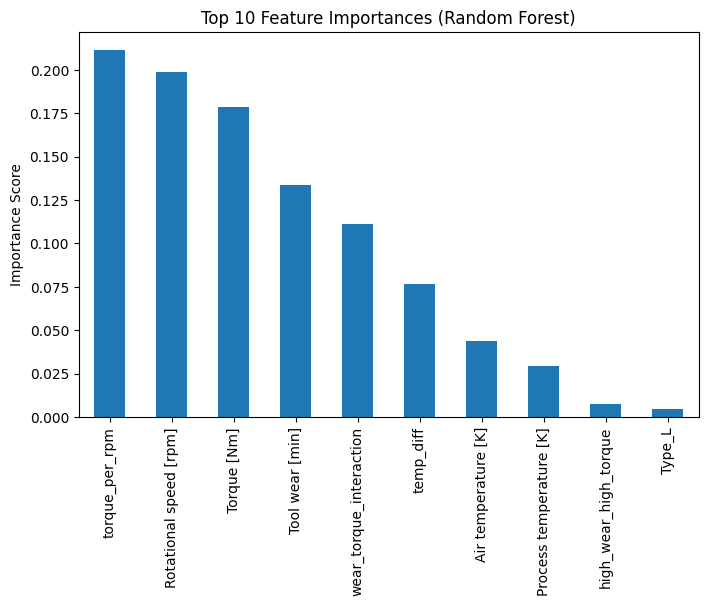

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.ylabel("Importance Score")
plt.show()


In [65]:
failure_index = y_test[y_test == 1].index[0]
failure_sample = X_test_fe.loc[[failure_index]]
failure_sample


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M,temp_diff,torque_per_rpm,wear_torque_interaction,high_wear_high_torque
4851,303.7,312.1,1363,51.8,90,True,False,8.4,0.038004,4662.0,0


In [66]:
rf_model.predict_proba(failure_sample)


array([[0.51666667, 0.48333333]])

In [67]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_proba_rf = rf_model.predict_proba(X_test_fe)[:, 1]

# Scores
roc_auc = roc_auc_score(y_test, y_proba_rf)
pr_auc = average_precision_score(y_test, y_proba_rf)

roc_auc, pr_auc


(np.float64(0.9629917184265011), np.float64(0.853811325051828))

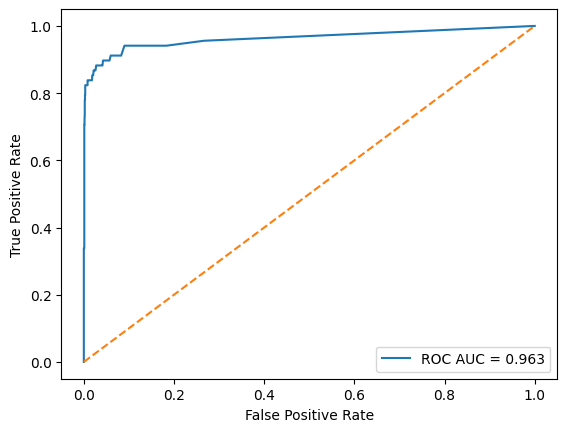

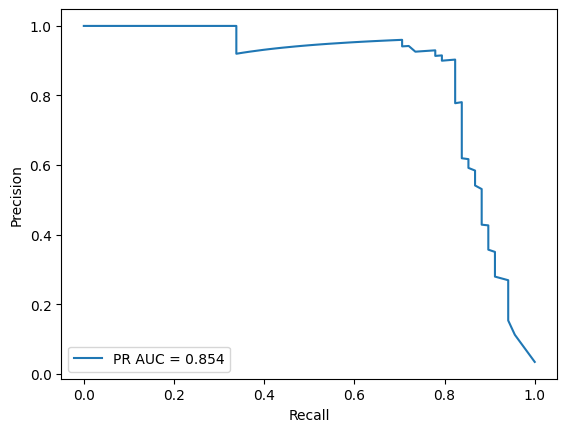

In [68]:
# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Precision–Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba_rf)
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


In [69]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_fe, y_train)

rf_smote = RandomForestClassifier(
    n_estimators=300,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_sm, y_train_sm)

y_pred_sm = rf_smote.predict(X_test_fe)
print(classification_report(y_test, y_pred_sm))


              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.60      0.79      0.68        68

    accuracy                           0.97      2000
   macro avg       0.80      0.89      0.84      2000
weighted avg       0.98      0.97      0.98      2000



In [70]:
pip install shap


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:

import numpy as np

np.array(shap_values).shape


NameError: name 'shap_values' is not defined

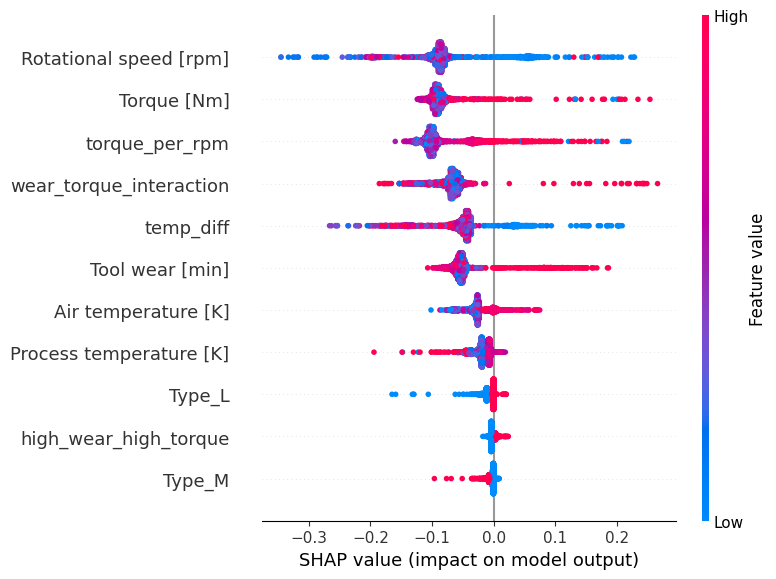

In [ ]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(X_test_fe)

# For binary classification → class 1
shap.summary_plot(shap_values[:, :, 1], X_test_fe)


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_recall = cross_val_score(
    rf_model,
    X_train_fe,
    y_train,
    cv=cv,
    scoring='recall'
)

cv_precision = cross_val_score(
    rf_model,
    X_train_fe,
    y_train,
    cv=cv,
    scoring='precision'
)

cv_recall.mean(), cv_precision.mean()


(np.float64(0.6790572390572391), np.float64(0.9436329910014122))

In [ ]:
FP = 4
FN = 18

cost_fp = 5000
cost_fn = 50000

total_cost = FP * cost_fp + FN * cost_fn
total_cost


920000

In [ ]:
y_proba_rf = rf_model.predict_proba(X_test_fe)[:, 1]

risk_score = y_proba_rf * 100


In [ ]:
def risk_category(score):
    if score < 40:
        return "Normal"
    elif score < 70:
        return "Monitor"
    elif score < 85:
        return "Warning"
    else:
        return "Critical"

risk_labels = [risk_category(s) for s in risk_score]
print(risk_labels)


['Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Monitor', 'Normal', 'Normal', 'Normal', 'Critical', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Critical', 'Normal', 'Normal', 'Monitor', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Critical', 'Monitor', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Warning', 'Normal', 'Normal',

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_proba_rf = rf_model.predict_proba(X_test_fe)[:, 1]


In [ ]:
cost_fp = 5000
cost_fn = 50000


In [ ]:
thresholds = np.arange(0.1, 0.95, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    total_cost = fp * cost_fp + fn * cost_fn
    
    results.append((t, total_cost, fp, fn))

results


[(np.float64(0.1), np.int64(675000), np.int64(55), np.int64(8)),
 (np.float64(0.15000000000000002),
  np.int64(705000),
  np.int64(31),
  np.int64(11)),
 (np.float64(0.20000000000000004),
  np.int64(630000),
  np.int64(16),
  np.int64(11)),
 (np.float64(0.25000000000000006),
  np.int64(650000),
  np.int64(10),
  np.int64(12)),
 (np.float64(0.30000000000000004),
  np.int64(635000),
  np.int64(7),
  np.int64(12)),
 (np.float64(0.3500000000000001), np.int64(680000), np.int64(6), np.int64(13)),
 (np.float64(0.40000000000000013),
  np.int64(730000),
  np.int64(6),
  np.int64(14)),
 (np.float64(0.45000000000000007),
  np.int64(770000),
  np.int64(4),
  np.int64(15)),
 (np.float64(0.5000000000000001), np.int64(920000), np.int64(4), np.int64(18)),
 (np.float64(0.5500000000000002),
  np.int64(1060000),
  np.int64(2),
  np.int64(21)),
 (np.float64(0.6000000000000002),
  np.int64(1410000),
  np.int64(2),
  np.int64(28)),
 (np.float64(0.6500000000000001),
  np.int64(1610000),
  np.int64(2),
  np.i

In [ ]:
best = min(results, key=lambda x: x[1])
best


(np.float64(0.20000000000000004), np.int64(630000), np.int64(16), np.int64(11))

In [72]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")

['rf_model.pkl']

In [73]:
best_threshold = 0.65   # use YOUR optimized value

joblib.dump(best_threshold, "threshold.pkl")

['threshold.pkl']

In [74]:
joblib.dump(X_train_fe.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [75]:
def engineer_features(df):
    df = df.copy()

    df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
    df['torque_per_rpm'] = df['Torque [Nm]'] / df['Rotational speed [rpm]']
    df['wear_torque_interaction'] = df['Tool wear [min]'] * df['Torque [Nm]']

    df['high_wear_high_torque'] = (
        (df['Tool wear [min]'] > df['Tool wear [min]'].median()) &
        (df['Torque [Nm]'] > df['Torque [Nm]'].median())
    ).astype(int)

    return df